In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("gold_price_data.csv")
df.head(3106)

,Date,Price,Open,High,Low,Volume,Chg%
0,2026-01-02,135793,136143,137037,135525,51877,0.02
1,2026-01-01,135771,135687,135850,135001,14622,0.23
2,2025-12-31,135454,136526,136527,134866,59050,1.10
3,2025-12-30,133974,133185,134880,132853,36733,1.04
4,2025-12-29,132595,137628,138269,131695,90640,-3.77
...,...,...,...,...,...,...,...
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3102,2014-01-02,29975,29678,30050,29678,3140,1.47


In [23]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head(3106)

,Date,Price,Open,High,Low,Volume,Chg%
3103,2014-01-01,29542,29435,29598,29340,2930,0.25
3102,2014-01-02,29975,29678,30050,29678,3140,1.47
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55
...,...,...,...,...,...,...,...
4,2025-12-29,132595,137628,138269,131695,90640,-3.77
3,2025-12-30,133974,133185,134880,132853,36733,1.04
2,2025-12-31,135454,136526,136527,134866,59050,1.10
1,2026-01-01,135771,135687,135850,135001,14622,0.23


In [24]:
# Remove % symbol and convert to number
df['Chg%'] = df['Chg%'].astype(str).str.replace('%', '')
df['Chg%'] = pd.to_numeric(df['Chg%'], errors='coerce')

# Drop missing values
df = df.dropna()

In [37]:
# Convert date to numeric
df['Days'] = df['Date'].map(pd.Timestamp.toordinal)
df['Year'] = df['Date'].dt.year

# 🔥 IMPORTANT CHANGE (future prediction)
df['Next_Price'] = df['Price'].shift(-1)

# Remove last row (NaN)
df = df.dropna()

# Features (input)
X = df[['Price','Open','High','Low','Volume']]

# Target (output)
y = df['Next_Price']

In [38]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

print("Model trained successfully ✅")

Model trained successfully ✅


In [39]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)
print("Accuracy (R2 Score):", r2_score(y, y_pred))

Accuracy (R2 Score): 0.9999185134667746


In [40]:
future_years = pd.date_range(start="2027-01-01", end="2032-01-01", freq='D')

future_df = pd.DataFrame({'Date': future_years})

# CORRECT (no typo)
future_df['Days'] = future_df['Date'].map(pd.Timestamp.toordinal)
future_df['Year'] = future_df['Date'].dt.year

In [48]:
# Take last actual price
last_price = df.iloc[-1]['Price']

# Years to predict
years = list(range(2027, 2033))

# 5% yearly growth
growth_rate = 0.05

predictions = []

for i, year in enumerate(years):
    price = last_price * ((1 + growth_rate) ** (i+1))
    predictions.append(price)
    print(f"{year} → Predicted Gold Price: ₹{int(price)}")

2027 → Predicted Gold Price: ₹142559
2028 → Predicted Gold Price: ₹149687
2029 → Predicted Gold Price: ₹157171
2030 → Predicted Gold Price: ₹165030
2031 → Predicted Gold Price: ₹173282
2032 → Predicted Gold Price: ₹181946


In [52]:
future_df['Predicted Price'] = model.predict(
    future_df[['Price','Open','High','Low','Volume']]
)

future_df

,Date,Days,Year,Price,Open,High,Low,Volume,Predicted Price
0,2027-01-01,739982,2027,135771,135687.00,135850.0,135001.00,14622.00,135742.980
1,2027-01-02,739983,2027,135771,137043.87,137208.5,136351.01,14695.11,135926.005
2,2027-01-03,739984,2027,135771,138400.74,138567.0,137701.02,14768.22,135194.850
3,2027-01-04,739985,2027,135771,139757.61,139925.5,139051.03,14841.33,135194.850
4,2027-01-05,739986,2027,135771,141114.48,141284.0,140401.04,14914.44,135194.850
...,...,...,...,...,...,...,...,...,...
1822,2031-12-28,741804,2031,135771,2607904.14,2611037.0,2594719.22,147828.42,134757.725
1823,2031-12-29,741805,2031,135771,2609261.01,2612395.5,2596069.23,147901.53,134757.725
1824,2031-12-30,741806,2031,135771,2610617.88,2613754.0,2597419.24,147974.64,134757.725
1825,2031-12-31,741807,2031,135771,2611974.75,2615112.5,2598769.25,148047.75,134757.725


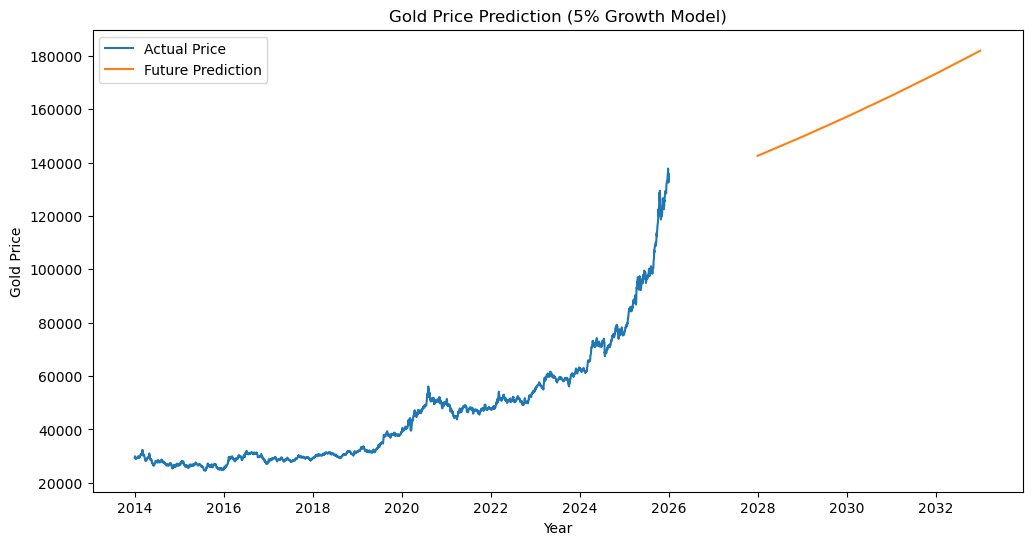

In [54]:
plt.figure(figsize=(12,6))

# Actual data
plt.plot(df['Date'], df['Price'], label="Actual Price")

# Future data
future_dates = pd.date_range(start="2027-01-01", periods=len(predictions), freq='YE')
plt.plot(future_dates, predictions, label="Future Prediction")

plt.xlabel("Year")
plt.ylabel("Gold Price")
plt.title("Gold Price Prediction (5% Growth Model)")
plt.legend()

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=300)